# Import Library

In [1]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import pillow_heif
import seaborn as sns
import sys
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import legacy as legacy_optimizers
from tensorflow.keras import mixed_precision

In [2]:
strategy = tf.distribute.get_strategy()
print("Number of replicas : ", strategy.num_replicas_in_sync)
print('TensorFlow : ', tf.__version__)
print('Python     : ', sys.version.split()[0])

num_gpus = len(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available : ", num_gpus)
print("Using device       : ", tf.test.gpu_device_name())

Number of replicas :  1
TensorFlow :  2.10.1
Python     :  3.10.18
Num GPUs Available :  1
Using device       :  /device:GPU:0


In [3]:
if num_gpus > 0:
    print("✅ GPU is available")
else:
    print("❌ GPU is unavailable")

✅ GPU is available


# Load Dataset

In [2]:
day = r"C:\DATA SEKUNDER\Day"
night = r"C:\DATA SEKUNDER\Night"

day_Resized = r"C:\DATA SEKUNDER\Resized\Day"
night_Resized = r"C:\DATA SEKUNDER\Resized\Night"

os.makedirs(day_Resized, exist_ok=True)
os.makedirs(night_Resized, exist_ok=True)

In [5]:
mixed_precision.set_global_policy('float32')
print("Precision Policy:", mixed_precision.global_policy())

tf.keras.mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)

Precision Policy: <Policy "float32">


## Image Resize

In [3]:
def resize_images(input_dir, output_dir, size=(256, 256)):
    for f in os.listdir(input_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(input_dir, f)
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(size)
                img.save(os.path.join(output_dir, f))
            except Exception as e:
                print(f"Gagal resize {f}: {e}")

resize_images(day, day_Resized)
resize_images(night, night_Resized)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
strategy = tf.distribute.MirroredStrategy()
print("GPU Devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
GPU Devices: 1


In [46]:
day_images = tf.io.gfile.glob(os.path.join(day_Resized, "*.jpg"))
night_images = tf.io.gfile.glob(os.path.join(night_Resized, "*.jpg"))

print(f"Total Day : {len(day_images)}")
print(f"Total Night : {len(night_images)}")

Total Day : 9000
Total Night : 6000


In [25]:
def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [256,256])
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0   
    return image

BATCH_SIZE = 2
day_ds = tf.data.Dataset.from_tensor_slices(day_images).map(preprocess_image, num_parallel_calls=AUTOTUNE)
night_ds = tf.data.Dataset.from_tensor_slices(night_images).map(preprocess_image, num_parallel_calls=AUTOTUNE)
day_ds = day_ds.shuffle(1000).batch(1).prefetch(AUTOTUNE)
night_ds = night_ds.shuffle(1000).batch(1).prefetch(AUTOTUNE)

In [26]:
class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.scale = self.add_weight(name="scale", shape=(channels,),initializer="ones", trainable=True, dtype=tf.float32)
        self.offset = self.add_weight(name="offset", shape=(channels,),initializer="zeros", trainable=True, dtype=tf.float32)

    def call(self, x):
        x32 = tf.cast(x, tf.float32)
        mean, var = tf.nn.moments(x32, axes=[1, 2], keepdims=True)
        inv = tf.math.rsqrt(var + self.epsilon)
        normalized = (x32 - mean) * inv
        out = self.scale * normalized + self.offset
        return tf.cast(out, x.dtype)

In [27]:
def Generator(input_shape=(256, 256, 3), ngf=32, n_down=3):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    skips = []

    # Encoder (Downsampling)
    for i in range(n_down):
        filters = ngf * (2 ** i)
        x = layers.Conv2D(filters, 4, strides=2, padding='same', use_bias=False)(x)
        if i != 0:
            x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        skips.append(x)

    # Bottleneck
    bottleneck_filters = ngf * (2 ** n_down)
    x = layers.Conv2D(bottleneck_filters, 4, strides=1, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder (Upsampling)
    for i in reversed(range(n_down)):
        filters = ngf * (2 ** i)
        skip = skips[i]
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Concatenate()([x, skip])

    out = layers.Conv2DTranspose(3, 4, strides=1, padding='same', activation='tanh')(x)
    return Model(inputs, out, name="U_Net_Generator")

In [28]:
def Discriminator(input_shape=(256, 256, 3), ndf=32, n_layers=2):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(ndf, 4, strides=2, padding='same')(inp)
    x = layers.LeakyReLU(0.2)(x)

    nf_mult = 1
    for n in range(1, n_layers):
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n, 4)
        x = layers.Conv2D(ndf * nf_mult, 4,
                          strides=2 if n < n_layers - 1 else 1,
                          padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 4, strides=1, padding='same')(x)
    return Model(inp, out, name="PatchGAN_Discriminator")

In [29]:
# Mean Squared Error (MSE) is used for both generator and discriminator losses
mse = tf.keras.losses.MeanSquaredError()

# Discriminator Loss
def discriminator_loss(real, fake):
    real_loss = mse(tf.ones_like(real), real)   # Real images → should be 1
    fake_loss = mse(tf.zeros_like(fake), fake)  # Fake images → should be 0
    return 0.5 * (real_loss + fake_loss)        # Average the two losses

# Generator Loss
def generator_loss(fake):
    return mse(tf.ones_like(fake), fake) # Fake images → want them to look real

LAMBDA_CYCLE = 25.0  # Weight for cycle-consistency loss    
LAMBDA_IDENTITY = 4.0 # Weight for identity loss   

def cycle_loss(real, cycled):
    real = tf.cast(real, tf.float32)
    cycled = tf.cast(cycled, tf.float32)
    return LAMBDA_CYCLE * tf.reduce_mean(tf.abs(real - cycled)) # L1 loss (absolute difference)

def identity_loss(real, same):
    real = tf.cast(real, tf.float32)
    same = tf.cast(same, tf.float32)
    return LAMBDA_IDENTITY * 0.5 * tf.reduce_mean(tf.abs(real - same))

In [30]:
day2night_gen = Generator()      # Generator: Day → Night
night2day_gen = Generator()      # Generator: Night → Day
day_disc = Discriminator()       # Discriminator for Day domain
night_disc = Discriminator()     # Discriminator for Night domain 

initial_lr = 2e-4

# Steps per epoch are based on the smallest dataset size
steps_per_epoch = max(1, min(len(day_images), len(night_images)) // BATCH_SIZE)

# Define a piecewise learning rate decay
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=2e-4,
    first_decay_steps=steps_per_epoch * 30,
    t_mul=1.0,
    m_mul=0.9
)

gen_opt = legacy_optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5)
disc_opt = legacy_optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5)

In [33]:
@tf.function
def train_step(real_day, real_night):
    with tf.GradientTape() as tape:
        # Forward pass: generator
        fake_night = day2night_gen(real_day, training=True)
        fake_day = night2day_gen(real_night, training=True)

        # Cycle consistency
        cycled_day = night2day_gen(fake_night, training=True)
        cycled_night = day2night_gen(fake_day, training=True)

        # Identity mapping
        same_day = night2day_gen(real_day, training=True)
        same_night = day2night_gen(real_night, training=True)

        # Discriminator predictions
        D_real_day = day_disc(real_day, training=True)
        D_fake_day = day_disc(fake_day, training=True)
        D_real_night = night_disc(real_night, training=True)
        D_fake_night = night_disc(fake_night, training=True)

        # Generator losses
        G_day_loss = generator_loss(D_fake_day)
        G_night_loss = generator_loss(D_fake_night)
        cyc_loss = cycle_loss(real_day, cycled_day) + cycle_loss(real_night, cycled_night)
        id_loss = identity_loss(real_day, same_day) + identity_loss(real_night, same_night)

        total_day2night_loss = G_night_loss + cyc_loss + id_loss
        total_night2day_loss = G_day_loss + cyc_loss + id_loss

        # Discriminator losses
        D_day_loss = discriminator_loss(D_real_day, D_fake_day)
        D_night_loss = discriminator_loss(D_real_night, D_fake_night)

        # Total losses
        total_gen_loss = total_day2night_loss + total_night2day_loss
        total_disc_loss = D_day_loss + D_night_loss

    # Combine gradients
    gen_vars = day2night_gen.trainable_variables + night2day_gen.trainable_variables
    disc_vars = day_disc.trainable_variables + night_disc.trainable_variables

    gen_grads, disc_grads = tape.gradient([total_gen_loss, total_disc_loss],[gen_vars, disc_vars])

    gen_opt.apply_gradients(zip(gen_grads, gen_vars))
    disc_opt.apply_gradients(zip(disc_grads, disc_vars))

    return total_day2night_loss, total_night2day_loss, D_day_loss, D_night_loss

In [34]:
history = {
    'day2night_gen_loss': [],
    'night2day_gen_loss': [],
    'day_disc_loss': [],
    'night_disc_loss': []
}

EPOCHS = 15

for epoch in range(EPOCHS):
    start_time = time.time()
    print(f"\n{'='*20} Epoch {epoch+1}/{EPOCHS} {'='*20}")

    d2n_gen, n2d_gen, d_disc, n_disc, n_batches = 0, 0, 0, 0, 0

    # Iterate over the dataset (day and night paired)
    for real_day, real_night in tf.data.Dataset.zip((day_ds, night_ds)):
        try:
            d2n_gen_loss, n2d_gen_loss, d_disc_loss, n_disc_loss = train_step(real_day, real_night)
        except tf.errors.ResourceExhaustedError:
            print("⚠️ Skipping batch (OOM: GPU memory exhausted)")
            tf.keras.backend.clear_session()
            continue

        # Accumulate losses for averaging
        d2n_gen += d2n_gen_loss.numpy()
        n2d_gen += n2d_gen_loss.numpy()
        d_disc += d_disc_loss.numpy()
        n_disc += n_disc_loss.numpy()
        n_batches += 1

    # Compute average losses per epoch
    avg_d2n_gen = d2n_gen / n_batches
    avg_n2d_gen = n2d_gen / n_batches
    avg_d_disc = d_disc / n_batches
    avg_n_disc = n_disc / n_batches

    # Store values in history
    history['day2night_gen_loss'].append(avg_d2n_gen)
    history['night2day_gen_loss'].append(avg_n2d_gen)
    history['day_disc_loss'].append(avg_d_disc)
    history['night_disc_loss'].append(avg_n_disc)

    elapsed_time = time.time() - start_time
    print(
        f"{elapsed_time:.1f}s - "
        f"Day→Night Generator Loss: {avg_d2n_gen:.4f} | "
        f"Night→Day Generator Loss: {avg_n2d_gen:.4f} | "
        f"Day Discriminator Loss: {avg_d_disc:.4f} | "
        f"Night Discriminator Loss: {avg_n_disc:.4f}"
    )


Epoch 1/15
Day→Night Gen: 3.9089, Night→Day Gen: 3.9016, Day Disc: 0.2539, Night Disc: 0.2446

Epoch 2/15
Day→Night Gen: 2.8086, Night→Day Gen: 2.8058, Day Disc: 0.2343, Night Disc: 0.2286

Epoch 3/15
Day→Night Gen: 2.5503, Night→Day Gen: 2.5487, Day Disc: 0.2307, Night Disc: 0.2270

Epoch 4/15
Day→Night Gen: 2.4053, Night→Day Gen: 2.4042, Day Disc: 0.2289, Night Disc: 0.2264

Epoch 5/15
Day→Night Gen: 2.3051, Night→Day Gen: 2.3040, Day Disc: 0.2282, Night Disc: 0.2254

Epoch 6/15
Day→Night Gen: 2.2327, Night→Day Gen: 2.2315, Day Disc: 0.2276, Night Disc: 0.2249

Epoch 7/15
Day→Night Gen: 2.1761, Night→Day Gen: 2.1752, Day Disc: 0.2268, Night Disc: 0.2246

Epoch 8/15
Day→Night Gen: 2.1306, Night→Day Gen: 2.1295, Day Disc: 0.2268, Night Disc: 0.2246

Epoch 9/15
Day→Night Gen: 2.0892, Night→Day Gen: 2.0885, Day Disc: 0.2259, Night Disc: 0.2239

Epoch 10/15
Day→Night Gen: 2.0352, Night→Day Gen: 2.0345, Day Disc: 0.2257, Night Disc: 0.2240

Epoch 11/15
Day→Night Gen: 1.9829, Night→Day Gen

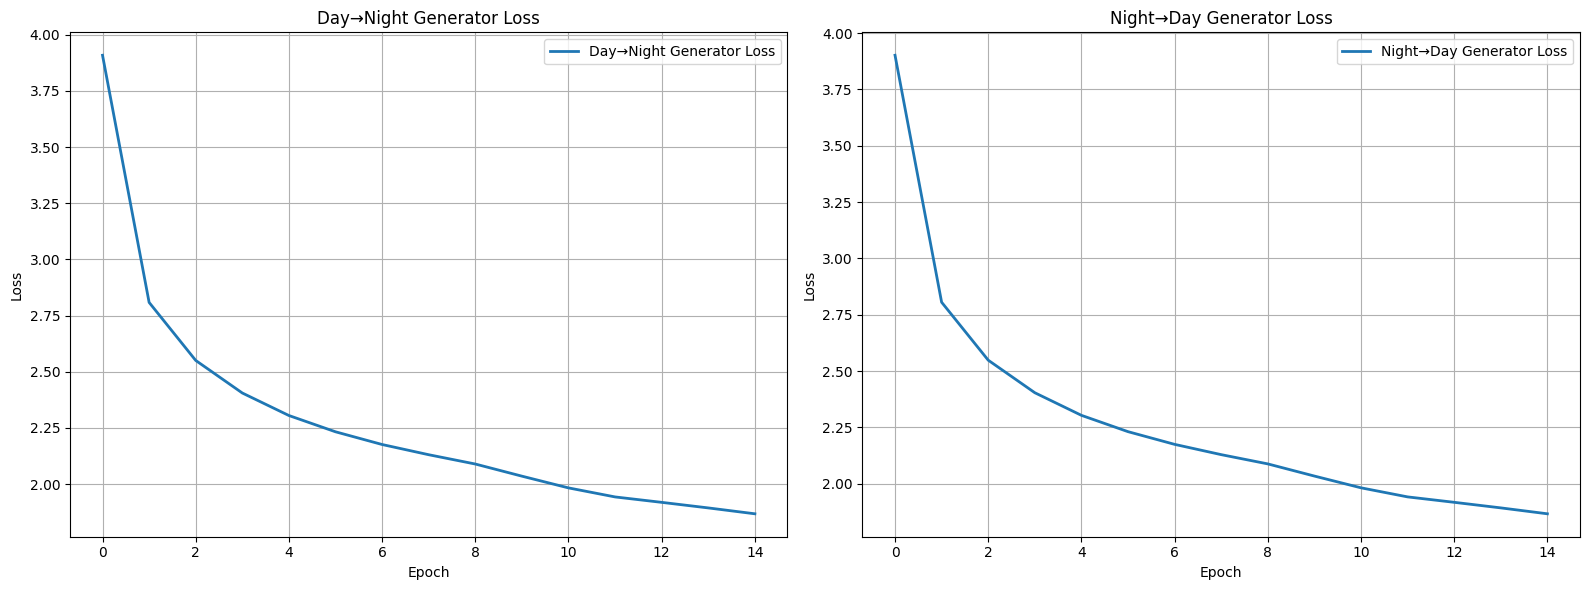

In [35]:
def plot_generator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['day2night_gen']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['day2night_gen'], label='Day→Night Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day→Night Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['night2day_gen'], label='Night→Day Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night→Day Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_generator_loss(history)

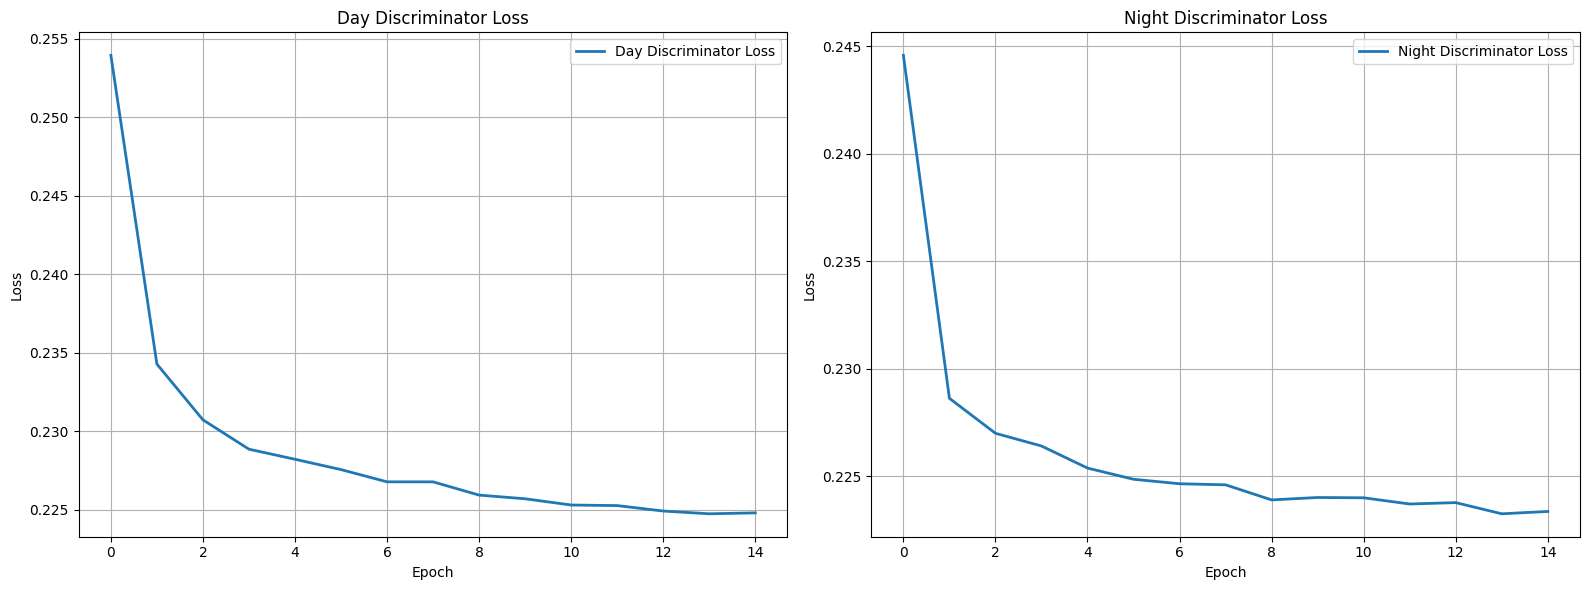

In [36]:
def plot_discriminator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['day_disc']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['day_disc'], label='Day Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['night_disc'], label='Night Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_discriminator_loss(history)

In [42]:
def display_generated_day2night(day2night_gen, day_dataset, num_images=5, start_from=1):
    plt.figure(figsize=(20, 10))
    ssim_scores = []

    # Ambil subset dari dataset
    selected_days = day_dataset.skip(start_from - 1).take(num_images)

    for i, real_day in enumerate(selected_days):
        # Jika dataset sudah batched, ambil 1 gambar
        if len(real_day.shape) == 4:
            real_day = real_day[0]
        real_day = tf.expand_dims(real_day, axis=0)  # (1, 256, 256, 3)

        # Generate hasil: Day → Night
        fake_night = day2night_gen(real_day, training=False)

        # Rescale ke [0, 1]
        def rescale(x): 
            return (x[0] * 0.5 + 0.5).numpy().clip(0, 1)
        
        real_day_rescaled = rescale(real_day)
        fake_night_rescaled = rescale(fake_night)

        # Hitung SSIM (kemiripan struktur)
        ssim_score = tf.image.ssim(real_day_rescaled, fake_night_rescaled, max_val=1.0).numpy()
        ssim_percent = ssim_score * 100
        ssim_scores.append(ssim_percent)

        # Plot dua baris: Original & Generated
        plt.subplot(2, num_images, i + 1)
        plt.imshow(real_day_rescaled)
        plt.title("Original Day", fontsize=18)
        plt.axis('off')

        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(fake_night_rescaled)
        plt.title(f"Generated Night\nSSIM: {ssim_percent:.2f}%", fontsize=16)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

    print(f"Average SSIM (Day→Night): {np.mean(ssim_scores):.2f}%")

    return ssim_scores


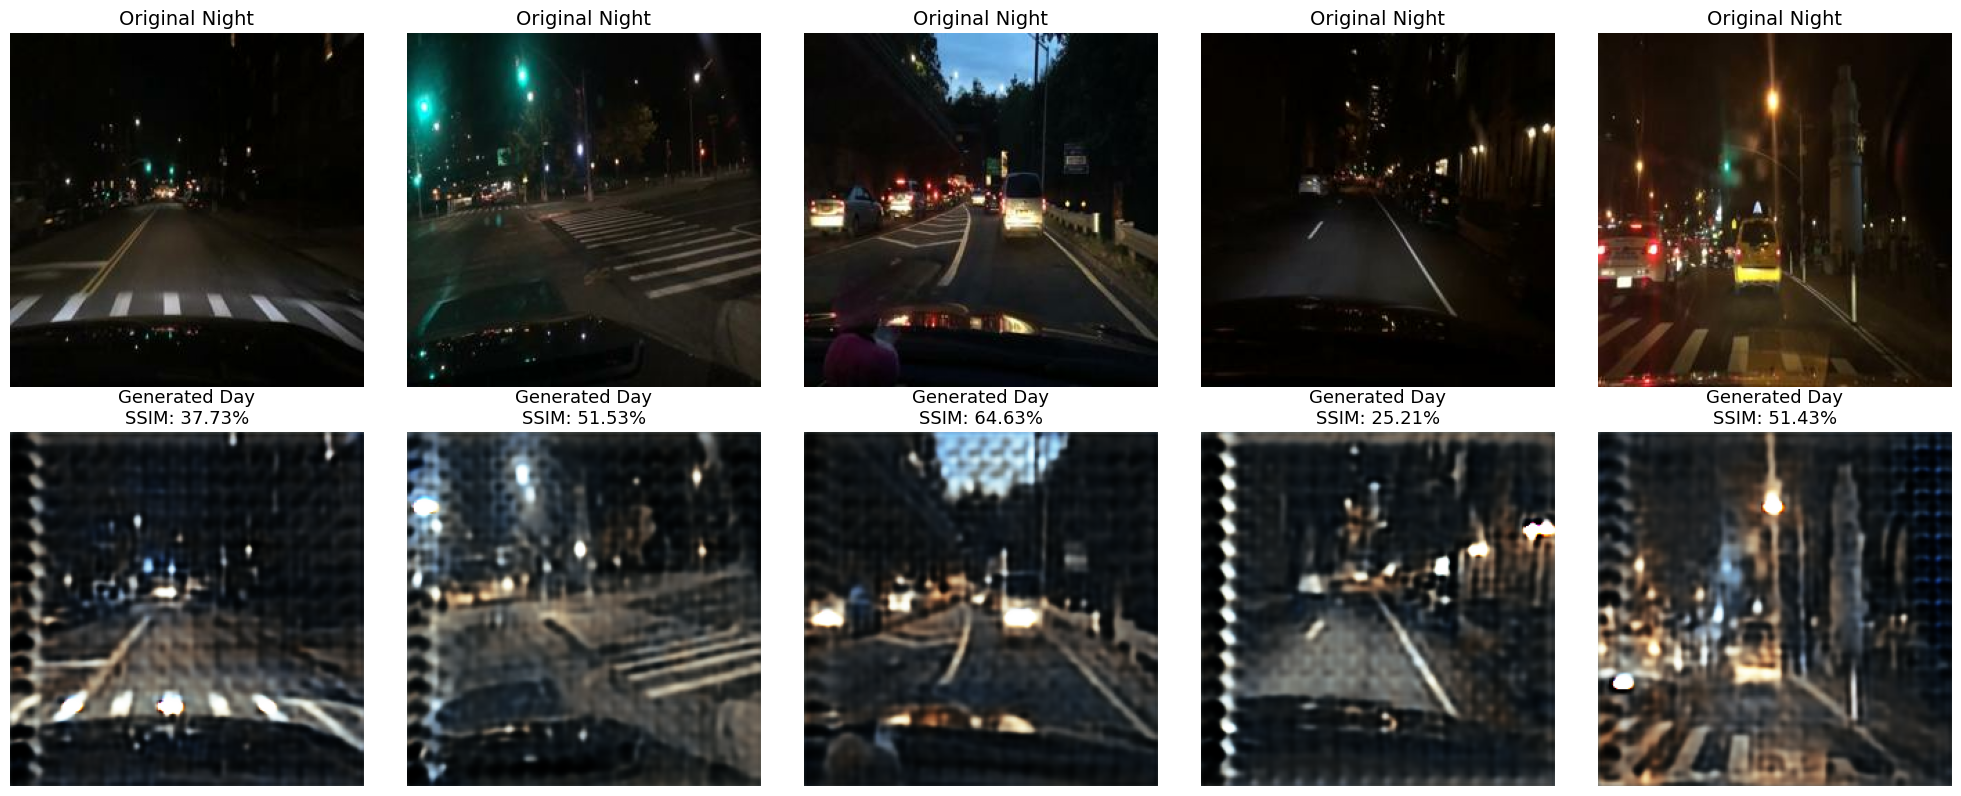

In [43]:
ssim_scores = display_generated_day2night(day2night_gen, day_ds, num_images=5)